# Russell-Reconstitution -- can you front-run the June reshuffle?
### The most predictable forced trade of the year -- and why you still can't get paid for it

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Front--runnable%3F: No](https://img.shields.io/badge/Front--runnable%3F-No-8b949e?style=flat-square)

Once a year, FTSE Russell rebuilds its US indices, and on the **reconstitution Friday** in late June every index fund must trade to the new membership -- one of the highest-volume closing auctions of the entire US year. The date is published *years* in advance and the flow only goes one way. Surely you can stand in front of that freight train and collect? That's the folklore. This notebook checks whether the small-cap *index* actually moves when you'd need it to.

> **This is the plain-language layer.** Want the Newey-West t-stat, the same-month control, the window-length sweep and the n=26 power calculation? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from russell_reconstitution import data, strategy as st

def _have_cache():
    try:
        data.fetch_daily("IWM", fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("IWM cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17, IWM)
R = dict(
    n=26, runup_days=5, runup_std_pct=2.7477,
    runup_mean_pct=0.5788, base_mean_pct=0.2150, excess_bps=36.39,
    up_rate_pct=61.54, base_up_rate_pct=55.25,
    t_vs_base=0.675, hac_t_excess=0.894, perm_p=0.5474,
    june_excess_bps=35.31, june_hac_t=0.868,
    event_day_mean_pct=0.0353, event_day_hac_t=-0.05,
    post_mean_pct=0.0175, post_hac_t=-0.325,
    gross_per_event_bps=57.88, net_per_event_bps=55.88,
    net_cum=1.145224, net_cagr_pct=0.5229,
    rd1_excess=-1.0, rd1_t=-0.05, rd3_excess=57.0, rd3_t=1.743,
    rd5_excess=36.4, rd5_t=0.894, rd10_excess=-41.5, rd10_t=-0.857,
    sp1_excess=45.89, sp1_t=0.719, sp2_excess=-39.92, sp2_t=-0.896,
    sp3_excess=94.71, sp3_t=1.499,
    year_start=2000, year_end=2025,
)

# Build the real event windows + baseline if the cache is present, else the synthetic NULL.
TAPE = "REAL (IWM, cached)" if HAVE_REAL else "SYNTHETIC null (offline fallback)"
if HAVE_REAL:
    BARS = data.fetch_daily("IWM", fetch=False)
else:
    BARS, _ = data.synthetic_daily(start_year=R['year_start'], end_year=R['year_end'],
                                   premium_bps=0.0, seed=320)
WIN = st.build_windows(BARS, runup_days=R['runup_days'])
BASE = st.runup_windows_baseline(BARS, runup_days=R['runup_days'])
print("tape:", TAPE, "| events:", len(WIN))


IWM cache present: True
tape: REAL (IWM, cached) | events: 26


## The answer first

| Question | Answer |
|---|---|
| Is there a real run-up into the Russell reshuffle? | **No.** The small-cap index (IWM) drifts up **+0.58%** over the five sessions before reconstitution Friday -- but the index drifts up on *any* random five-session stretch (+0.22%). The **+36 bps** extra is noise. |
| Is it statistically real? | **No.** HAC *t* = **+0.89**, permutation *p* = **0.55** -- nowhere near the desk's |t| >= 2 bar. |
| Does the reconstitution day itself pop? | **No.** The famous high-volume Friday moves ~**+0.04%** -- a coin flip. Huge *volume*, no *price*. |
| Could you trade it? | **No.** Even taken at face value it's ~**+0.5%/yr** while you sit in cash 360 days -- and there's no significant edge underneath it anyway. |

> A textbook **None / Mirage**: the forced flow is real and enormous, but it's so predictable that the *index price* is already efficient by the time you could trade it. Big volume is not the same thing as a tradable move.

## 1 - The claim

> *"The Russell reconstitution forces billions of dollars of one-directional small-cap buying into one closing auction in late June. The date is on the calendar years ahead. Buy the index before it and ride the wave."*

Every June FTSE Russell recomputes the Russell 1000 / 2000 / 3000 from a late-May snapshot, publishes the new lists in mid-June, and makes them **effective after the close of the reconstitution Friday** (traditionally the last Friday of June). Index funds that track these benchmarks *must* hold the new weights by that close, so a giant, mechanical, pre-announced trade lands in that one session.

## 2 - So what?

If the index reliably popped into a date you can mark on a calendar, that would be a free lunch: no forecasting, no stock-picking, just show up once a year. It would also tell us something deep -- that even *fully transparent* forced flow moves prices. The more likely story is the opposite: because everyone can see it coming, the run-up is exactly the thing that gets competed away. This study is about which world we live in.

## 3 - How would we even know?

Three traps to avoid:

1. **The wrong null.** Small-caps drift up over time, so *any* five-day window tends to be positive. The honest question is whether the run-up beats a **random five-day window**, not zero.
2. **Is it Russell, or is it June?** June might just be a good month for small-caps. So we also compare against a **same-month (June) baseline**.
3. **Tiny n.** One reconstitution a year means only **26 events** (2000-2025). With small-caps that volatile, an effect has to be *huge* to show up as real -- and a handful of years can look impressive by pure chance.

We test on the IWM (iShares Russell 2000) daily tape, with the reconstitution Fridays hardcoded from the FTSE Russell calendar in this study's `data.py`.

## 4 - The teardown -- let's actually look

**First, meet the data:** the five-session run-up into each reconstitution Friday, compared with the everyday five-session drift.

In [2]:
et = data.recon_table()
print('Reconstitution events:', len(et), f"({et['year'].min()}-{et['year'].max()})")
print('Every event weekday:', sorted(et['weekday'].unique()), '(4 = Friday)')
if HAVE_REAL:
    rm = float(WIN['runup_ret'].mean()*100)
    bm = float(BASE.mean()*100)
    up = float((WIN['runup_ret']>0).mean()*100)
else:
    rm, bm, up = R['runup_mean_pct'], R['base_mean_pct'], R['up_rate_pct']
print()
print(f'5-session run-up mean:      {rm:+.4f}%')
print(f'Everyday 5-session drift:   {bm:+.4f}%  <- the honest baseline')
print(f'Run-up up-rate:             {up:.1f}% of years')
print(f'[tape: {TAPE}]')

Reconstitution events: 26 (2000-2025)
Every event weekday: [np.int64(4)] (4 = Friday)

5-session run-up mean:      +0.5788%
Everyday 5-session drift:   +0.2150%  <- the honest baseline
Run-up up-rate:             61.5% of years
[tape: REAL (IWM, cached)]


**The run-up vs the everyday drift -- is the extra bit real, or just the usual drift?**

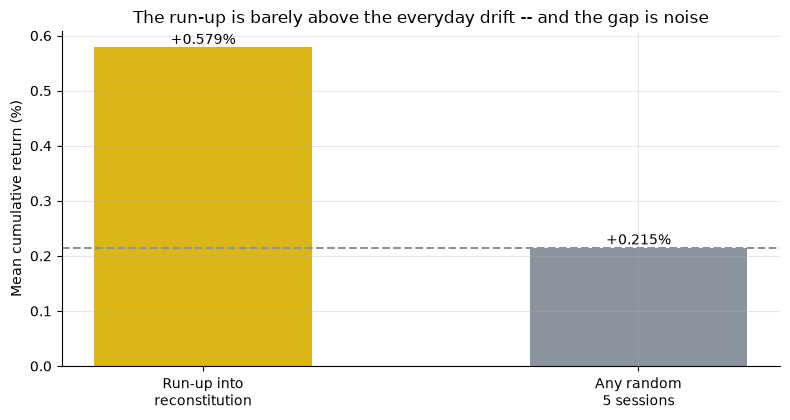

Excess over the everyday drift: +36.4 bps -- looks like something...
[tape: REAL (IWM, cached)]


In [3]:
if HAVE_REAL:
    rm = float(WIN['runup_ret'].mean()*100); bm = float(BASE.mean()*100)
else:
    rm, bm = R['runup_mean_pct'], R['base_mean_pct']

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['Run-up into\nreconstitution', 'Any random\n5 sessions'], [rm, bm],
              color=[AMBER, GREY], width=0.5)
ax.axhline(bm, ls='--', c=GREY, lw=1.5)
ax.set_ylabel('Mean cumulative return (%)')
ax.set_title('The run-up is barely above the everyday drift -- and the gap is noise')
for b, v in zip(bars, [rm, bm]):
    ax.annotate(f'{v:+.3f}%', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Excess over the everyday drift: {(rm-bm)*100:+.1f} bps -- looks like something...')
print(f'[tape: {TAPE}]')

There *is* a small positive gap -- about **+36 bps** over the everyday drift, up in **62%** of years. It looks like something. But with only 26 events and small-caps this jumpy, the real test is whether that gap is bigger than what pure chance throws up. (The quants notebook puts a t-stat on it: **+0.89** -- not even close.)

**The reconstitution day itself: all that volume, where's the price move?**

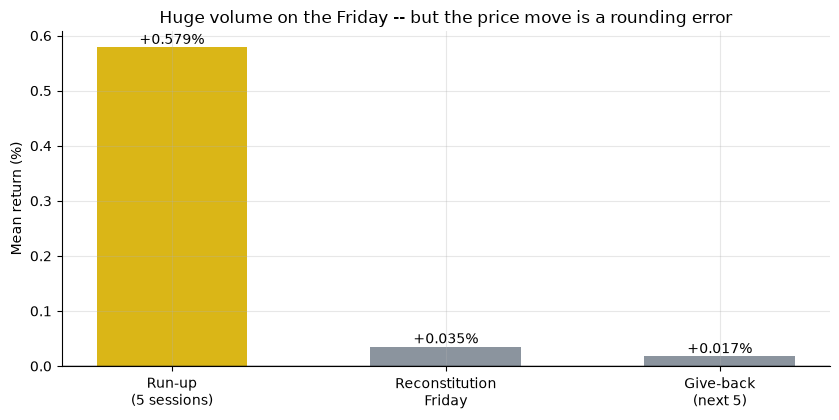

Reconstitution-Friday mean: +0.0353% -- a coin flip.
[tape: REAL (IWM, cached)]


In [4]:
if HAVE_REAL:
    ev = float(WIN['event_day_ret'].mean()*100)
    po = float(WIN['post_ret'].mean()*100)
else:
    ev, po = R['event_day_mean_pct'], R['post_mean_pct']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Run-up\n(5 sessions)', 'Reconstitution\nFriday', 'Give-back\n(next 5)'],
              [rm if HAVE_REAL else R['runup_mean_pct'], ev, po],
              color=[AMBER, GREY, GREY], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean return (%)')
ax.set_title('Huge volume on the Friday -- but the price move is a rounding error')
for b, v in zip(bars, [rm if HAVE_REAL else R['runup_mean_pct'], ev, po]):
    ax.annotate(f'{v:+.3f}%', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Reconstitution-Friday mean: {ev:+.4f}% -- a coin flip.')
print(f'[tape: {TAPE}]')

The reconstitution Friday -- the day of the famous closing-auction surge -- moves the *index* about **+0.04%**, and the week after gives back nothing in particular. The enormous volume reshuffles *which* small-caps are held; it does not push the basket up or down in a way you could have bet on.

## 5 - The verdict

- **Signal -- None.** Run-up excess +36 bps, HAC *t* = **+0.89**, perm *p* = 0.55; the reconstitution day and the give-back week are coin flips; the same-month June control doesn't change the story. Indistinguishable from noise.
- **Tradability -- Mirage.** Even at face value the front-run rule is ~+0.5%/yr while sitting in cash 360 days -- and there's no significant edge to harvest in the first place.
- **Front-runnable? -- No.** The flow is real and gigantic, but it's the most telegraphed trade of the year, so the index price is already efficient. Volume is not a price move.

## 6 - Could you actually trade it?

The 'strategy': buy IWM at the close five sessions before reconstitution Friday, sell on the event close, once a year. Gross, and net of a modest 1 bp one-way (2 bps round-trip) cost on NAV.

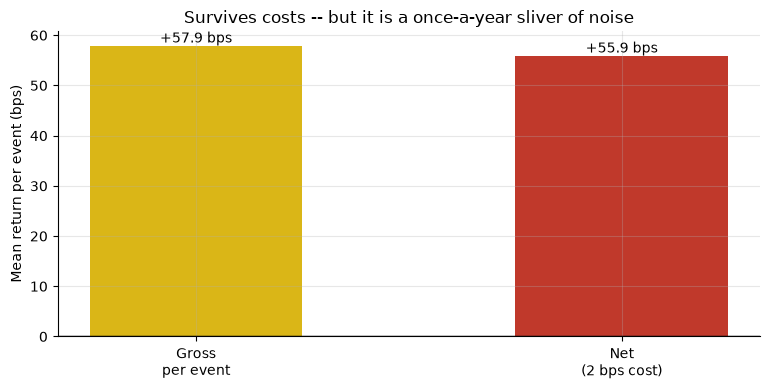

Net per event: +55.9 bps | compounded over 26 yrs: x1.145 (~0.52%/yr)
Costs are not the killer -- the absence of a real edge is. [tape: REAL (IWM, cached)]


In [5]:
if HAVE_REAL:
    tr = st.tradability(WIN['runup_ret'], cost_bps_oneway=1.0)
    g, nbps, ncum = tr['gross_mean_per_event']*1e4, tr['net_mean_per_event']*1e4, tr['net_cum_growth']
else:
    g, nbps, ncum = R['gross_per_event_bps'], R['net_per_event_bps'], R['net_cum']

fig, ax = plt.subplots(figsize=(7.8, 4.0))
bars = ax.bar(['Gross\nper event', 'Net\n(2 bps cost)'], [g, nbps], color=[AMBER, RED], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean return per event (bps)')
ax.set_title('Survives costs -- but it is a once-a-year sliver of noise')
for b, v in zip(bars, [g, nbps]):
    ax.annotate(f'{v:+.1f} bps', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Net per event: {nbps:+.1f} bps | compounded over 26 yrs: x{ncum:.3f} (~{(ncum**(1/26)-1)*100:.2f}%/yr)')
print('Costs are not the killer -- the absence of a real edge is. [tape: ' + TAPE + ']')

Costs barely register (one round-trip a year), so the rule 'survives costs' on paper -- but that's the wrong frame: there's no statistically real edge to begin with. A ~0.5%/yr contribution from a coin-flip signal, while parked in cash 360 days, is dominated by simply holding the index. **No signal, no vehicle.**

## 7 - Going further

- **The positive control:** the companion notebook plants a run-up premium into a synthetic tape and shows the machinery only detects it once it's *enormous* (~40 bps/day) -- because n=26 is so low-powered. The real tape's +36 bps cumulative is far below that floor.
- **The single-name cousin:** [Study 249 -- Index-Inclusion](../../249-index-inclusion/) tests the *individual stocks* added to the S&P 500 (the inclusion pop). That's a cross-section; this is the whole index on a calendar date -- two different angles on forced index flow.
- **A real calendar signal for contrast:** [Study 287 -- Easter-Effect](../../287-easter-effect/) runs the *same* event-study machinery and lands Real -- which is exactly why running the identical apparatus here and getting None is meaningful.

*Think the action is in the single names, not the index? Fork this and test the additions vs deletions spread around reconstitution -- but mind the survivorship and the borrow on the short leg.*